## 首先要定义状态结构

In [99]:
from typing_extensions import TypedDict
from typing import List, Dict, Any, Optional
from grid2op.Action import BaseAction
from grid2op.Observation import BaseObservation
from grid2op.Environment import Environment
from pydantic import BaseModel, Field, field_validator
from langchain_core.messages import BaseMessage, SystemMessage


# 用于预测下一个agent的动作选择是什么
class Prediction(TypedDict):
    action: str
    args: Optional[List[str]]

class AgentState(BaseModel):
    env_name:str =Field(default_factory=lambda: "l2rpn_case14_sandbox")
    env_id: str = Field(default_factory=lambda: "l2rpn_case14_sandbox")
    actions: List[str] = Field(default_factory=list)  # 已执行的节点动作
    # observations: List[BaseObservation] = Field(default_factory=list)  # 当前的环境观察状态
    scratchpad: List[BaseMessage] = Field(default_factory=list) #记录经过节点的综合过程
    prediction: Prediction = Field(default_factory=lambda: {"action": "do_nothing", "args": []}) # 智能体的输出
    responses: Dict[str, Any] = Field(default_factory=dict) # 工具的调用回复
    plan: List[str] = Field(default_factory=list)
    human_feedback: List[str] = Field(default_factory=list)
    # class Config:
    #     arbitrary_types_allowed = True  # 允许任意类型


# class AgentState(TypedDict):
#     env_name: str
#     env_id: str
#     actions: List[str]
#     scratchpad: List[BaseMessage]
#     prediction: Prediction
#     responses: Dict[str, Any]
#     plan: List[str]
#     human_feedback: List[str]




## 定义工具

In [100]:
import sys
import logging
import numpy as np
import uuid
import matplotlib.pyplot as plt

#首先定义工具节点
from langchain_core.messages import AIMessage
from langchain_core.tools import tool

import grid2op
from typing import List, Dict, Any
from datetime import datetime
from grid2op.PlotGrid import PlotMatplot
from grid2op.Action import PlayableAction
from grid2op.Parameters import Parameters


# 设置日志配置
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 在脚本的顶层定义 env_registry 作为全局变量
env_registry = {}
# 函数中引用该全局变量
def env_register(env_id, env):
    global env_registry  # 声明使用全局变量
    env_registry[env_id] = env


### 定义环境创建工具，这样可以初始化环境

In [101]:
import uuid
from grid2op.Parameters import Parameters
from grid2op.Action import PlayableAction
import grid2op
import logging

# 假设已经定义了 logger
logger = logging.getLogger(__name__)

@tool
def create_environment(state: AgentState, param=None, bk_cls=None) -> AgentState:
    """
    创建并注册一个grid2op环境，并选择合适的后端。
    参数：
    - state: AgentState 对象，包含 agent 的当前状态。
    - param: dict，传递给环境的参数，默认为 Parameters()。
    - bk_cls: class，后端类，默认为 LightSimBackend。

    返回：
    - 更新后的 AgentState 对象。
    """
    try:
        env_name = state.env_name  # 从 AgentState 中获取环境名称或 ID
        env_id = state.env_id or str(uuid.uuid4())  # 如果没有提供 env_id，则生成一个唯一的 UUID

        # 设置默认参数
        param = param or Parameters()  # 确保 param 有默认值

        # 默认选择后端
        if bk_cls is None:
            try:
                from lightsim2grid import LightSimBackend
                bk_cls = LightSimBackend
                logger.info("成功导入 LightSimBackend，用于更快的后端计算。")
            except ImportError as exc:
                logger.warning(f"导入 LightSimBackend 时发生错误：{exc}，将使用 PandaPowerBackend 作为后备方案。")
                from grid2op.Backend import PandaPowerBackend
                bk_cls = PandaPowerBackend

        # 设置环境
        env = grid2op.make(env_name, action_class=PlayableAction, param=param, backend=bk_cls())
        logger.info(f"环境 '{env_name}' 创建成功，使用后端: {bk_cls.__name__}。")

        # 检查并初始化环境注册器
        global env_registry
        if 'env_registry' not in globals():
            env_registry = {}
            logger.info("环境注册器未定义，已初始化 env_registry。")

        # 注册环境
        env_registry[env_id] = env
        logger.info(f"环境 '{env_id}' 注册成功。")

        # 更新 AgentState
        state.responses = {
            "status": "success",
            "message": f"环境 '{env_name}' 创建并注册成功。",
            "action": "create_environment",
            "data": {"env": env, "env_id": env_id}
        }
        # state.observations.append(env.get_obs())  # 将环境的观测状态加入到 observations 中


        return state   # 返回更新后的 AgentState

    except Exception as e:
         
        
        logger.error(f"创建或注册环境 '{env_name}' 失败，错误信息：{str(e)}")
        state.responses = {
                            "status": "failure",
                            "message": f"创建或注册环境时出错: {str(e)}",
                            "action":"create_environment",
                            "data": None
                          }
        return state   # 返回包含错误信息的 AgentState

### 获取环境观测

In [102]:
from typing import Dict, Any
@tool
def get_obs_by_id(state: AgentState) -> AgentState:
    """
    根据环境的注册ID获取grid2op环境的当前状态，并更新 AgentState。

    参数:
    - state: AgentState，包含当前代理的状态，其中包括要查询的环境ID。

    返回:
    - 更新后的 AgentState，包含环境的观测状态和响应消息。
    """
    try:
        env_id = state.env_id  # 从 AgentState 中获取环境ID

        # 1. 检查是否已注册该环境
        if env_id not in env_registry:
            raise ValueError(f"环境ID {env_id} 未注册，无法获取状态。")
        
        # 2. 获取已注册的环境对象
        env = env_registry[env_id]
        
        # 3. 获取当前的观测状态
        observation = env.get_obs()  # 获取当前观测状态
        
        # 4. 提取观测状态并格式化为易于理解的字典
        observation_data = {
            "gen_p": observation.prod_p.tolist(),  # 发电机有功功率
            "gen_q": observation.prod_q.tolist(),  # 发电机无功功率
            "gen_v": observation.prod_v.tolist(),  # 发电机电压
            "gen_theta": observation.gen_theta.tolist(),  # 发电机相位角
            "load_p": observation.load_p.tolist(),  # 负载有功功率
            "load_q": observation.load_q.tolist(),  # 负载无功功率
            "load_v": observation.load_v.tolist(),  # 负载电压
            "load_theta": observation.load_theta.tolist(),  # 负载相位角
            "p_or": observation.p_or.tolist(),  # 线路一端有功功率
            "q_or": observation.q_or.tolist(),  # 线路一端无功功率
            "v_or": observation.v_or.tolist(),  # 线路一端电压
            "a_or": observation.a_or.tolist(),  # 线路一端相位角
            "theta_or": observation.theta_or.tolist(),  # 线路一端角度
            "p_ex": observation.p_ex.tolist(),  # 线路另一端有功功率
            "q_ex": observation.q_ex.tolist(),  # 线路另一端无功功率
            "v_ex": observation.v_ex.tolist(),  # 线路另一端电压
            "a_ex": observation.a_ex.tolist(),  # 线路另一端相位角
            "theta_ex": observation.theta_ex.tolist(),  # 线路另一端角度
            "rho": observation.rho.tolist(),  # 线路上的功率流（rho）
            "topo_vect": observation.topo_vect.tolist(),  # 拓扑结构
            "line_status": observation.line_status.tolist(),  # 线路状态 (1: 正常, 0: 断开)
        }

        # 5. 更新 AgentState 的观测状态和响应消息
        # state.observations.append(observation)  # 更新 observations
        state.responses = {
            "status": "success",
            "message": "环境状态获取成功",
            "action":"get_obs_by_id",
            "data": observation_data
        }  # 更新 responses

        return state  # 返回更新后的 AgentState
    
    except Exception as e:
        # 处理异常并更新状态
        state.responses = {
            "status": "failure",
            "message": f"获取环境状态时出错: {str(e)}",
            "action":"get_obs_by_id",
            "data": None
        }
        return state  # 返回包含错误信息的 AgentState

### 定义画图工具

In [103]:
from typing import Any
@tool
def plot_layout_by_env_id(state: AgentState) -> AgentState:
    """
    根据提供的环境ID绘制电网布局图，并更新 AgentState。

    该工具通过调用 PlotMatplot 的 plot_layout 方法绘制指定电网环境的布局图。
    生成的图像将保存为 'grid_layout.png'，并显示图像。

    Args:
        state (AgentState): 包含代理状态信息的对象，包括环境ID。

    Returns:
        AgentState: 更新后的代理状态，包含绘图结果或错误信息。
    """
    try:
        env_id = state.env_id  # 从 AgentState 中获取环境ID
        if not env_id:
            raise ValueError("缺少 env_id 参数")
        
        logger.info(f"接收到绘制电网布局请求，env_id: {env_id}")
        
        # 获取环境
        env = env_registry.get(env_id)
        if env is None:
            raise ValueError(f"环境ID {env_id} 未注册，无法绘制布局。")
        
        # 使用 PlotMatplot 绘制布局
        plot_helper = PlotMatplot(env.observation_space)
        fig_layout = plot_helper.plot_layout()
        fig_layout.savefig('grid_layout.png')
        logger.info("电网布局绘制成功，并保存为 'grid_layout.png'")
        
        # 显示图像
        plt.show()

        # 更新 AgentState 的响应消息
        state.responses = {
            "status": "success",
            "message": "电网布局绘制成功，并保存为 'grid_layout.png'",
            "action":"plot_layout_by_env_id",
            "data": None
        }
        return state  # 返回更新后的 AgentState

    except Exception as e:
        logger.error(f"绘制电网布局时出错: {str(e)}")
        state.responses = {
            "status": "failure",
            "message": f"绘制电网布局时出错: {str(e)}",
            "action":"plot_layout_by_env_id",
            "data": None
        }
        return state  # 返回包含错误信息的 AgentState

### 定义功率重分配工具

In [104]:
from typing import Any
@tool
def redispatch(state: AgentState) -> AgentState:
    """
    根据提供的发电机ID和调整量进行功率重分配，并更新 AgentState。

    该工具接收包含环境ID、发电机ID和功率调整量的 AgentState，执行功率重分配操作。
    生成的结果将更新到 AgentState 中，返回成功或失败信息。

    Args:
        state (AgentState): 包含以下信息的状态对象:
            - env_id (str): 环境ID，用于标识需要进行功率调整的电网环境。
            - prediction (Prediction): 其中包含发电机ID和调整量的信息。

    Returns:
        AgentState: 更新后的 AgentState，包含功率重分配操作的结果或错误信息。
    """
    try:
        env_id = state.env_id  # 从 AgentState 中获取环境ID
        prediction = state.prediction
        gen_id = prediction.get("args")[0]  # 获取发电机ID
        amount = prediction.get("args")[1]  # 获取调整量

        logger.info(f"接收到 redispatch 请求，env_id: {env_id}, gen_id: {gen_id}, amount: {amount}")
        
        # 确保 amount 是一个列表
        if not isinstance(amount, list):
            amount = [amount]
        
        # 如果有多个发电机而只有一个调整量，则应用到所有发电机
        if len(gen_id) > 1 and len(amount) == 1:
            amount = amount * len(gen_id)
        
        # 获取环境对象
        env = env_registry.get(env_id)
        if env is None:
            raise ValueError(f"无法找到 env_id 为 {env_id} 的环境实例。")
        
        # 检查是否允许进行重分配操作
        if not env.redispatching_unit_commitment_availble:
            raise ValueError("当前环境不允许进行发电机功率重分配操作。")
        
        # 遍历发电机，检测是否可进行重分配
        for g_id in gen_id:
            if not env.gen_redispatchable[g_id]:
                raise ValueError(f"发电机 {g_id} 不允许进行功率重分配。")
        
        # 执行功率重分配操作
        param = [(g_id, a) for g_id, a in zip(gen_id, amount)]
        action = env.action_space({"redispatch": param})

        if action.is_ambiguous()[0]:
            info = action.ambiguous_info()[1]
            raise ValueError(f"动作是模糊的，无法执行。{info}")
        else:
            env.step(action) # 执行动作
            logger.info("成功进行发电机功率重分配。")
            state.responses = {
                "status": "success",
                "message": "成功进行发电机功率重分配。",
                "action": "redispatch",
                "data": action
            }  # 更新响应消息
            # state.observations.append(env.get_obs())  # 将新的观测状态添加到 observations
            return state  # 返回更新后的 AgentState

    except Exception as e:
        logger.error(f"处理 redispatch 请求时出错: {str(e)}")
        state.responses = {
            "status": "failure",
            "message": f"处理 redispatch 请求时出错: {str(e)}",
            "action":"redispatch",
            "data": None
        }
        return state  # 返回包含错误信息的 AgentState

## 定义智能体

### 定义指定决策顺序智能体

这里的思路是当一个任务开始的时候，需要先对人类的自然语言进行处理，让智能体将人类的自然语言处理成分步骤执行的子任务，然后储存在AgentState状态里面

In [105]:
import json
import time
from langchain_core.prompts.chat import ChatPromptTemplate, MessagesPlaceholder, HumanMessagePromptTemplate, SystemMessagePromptTemplate
from langchain_ollama import ChatOllama

def planning_node(state: AgentState , user_input, max_retries=3, retry_delay=2) -> AgentState:

    # 定义系统消息
    system_message = SystemMessagePromptTemplate.from_template(
        """
        你是一个负责管理电网的智能代理，专门用于规划电网操作。
        你的主要任务包括创建电网环境、初始化环境图、绘制电网布局以及进行发电机功率的重新分配。
        你需要根据用户提供的信息，规划出一系列具体的操作步骤。
    
        可用的操作包括：
        - "create_environment": 创建一个新的 grid2op 环境，并设置所需的后端参数。
        - "initialize_graph": 在现有的环境中初始化电网的图形表示，并提取最初的观测结果。
        - "plot_grid": 绘制当前电网的布局图，并能够将图像输出以供查看。
        - "redispatch": 根据电网的实时需求和发电情况，重新分配各个发电机的输出功率。
    
        你需要根据用户的描述，分析并规划出完成任务所需的具体步骤，包括操作的顺序和每个步骤的详细说明,请拆分成非常细的步骤。
        """
    )
    
    user_message = HumanMessagePromptTemplate.from_template(
        """
        根据以下指令，请你规划出详细的电网操作步骤：
        {user_input}
        请确保操作计划明确、完整，并包括所有必要的细节。
        请你使用如下JSON格式回复：
        {{
          "planned_steps": [
            {{
              "step_number": 1,
              "operation": "创建新的 grid2op 环境",
              "action_guidance": "调用 create_environment()，确保所有初始化参数已正确设置。"
            }},
            {{
              "step_number": 2,
              "operation": "初始化电网环境的图形表示",
              "action_guidance": "执行 initialize_graph()，加载当前电网配置并生成图形输出。"
            }},
            {{
              "step_number": 3,
              "operation": "绘制电网布局图",
              "action_guidance": "使用 plot_grid() 绘制和输出电网布局，确保所有元件都清晰可见。"
            }},
            {{
              "step_number": 4,
              "operation": "重新分配发电机功率",
              "action_guidance": "调用 redispatch(generator_id, power_adjustment)，根据需求和容量调整各发电机输出。"
            }}
          ]
        }}
            
        """
    )
    prompt = ChatPromptTemplate.from_messages([system_message, user_message])
    # llm = ChatOpenAI(model="deepseek-chat", temperature=0,
    #                 openai_api_base="https://api.deepseek.com", 
    #                 openai_api_key="sk-8e3a75c3f4f54d9c9fd7dd779dcd80a8"
    #                 ).bind(response_format={"type": "json_object"})
    llm = ChatOllama(model="llama3.2", temperature=0,format="json")

    planning_agent= prompt | llm

    
    attempts = 0
    while attempts < max_retries:
        try:
            json_response = planning_agent.invoke(user_input)
            response_dic = json.loads(json_response.content)
            # 如果返回成功，将规划放入state
            state.plan.append(response_dic["planned_steps"])
            return state
        except Exception as e:
            print(f"Attempt {attempts + 1} failed: {e}")
            time.sleep(retry_delay)  # 等待一定时间后重试
            attempts += 1
    print("多次尝试后仍未能获得有效响应。")
    # 如果所有重试都失败，更新状态以反映错误
    # state.feedback = "多次尝试后仍未能获得有效响应。."
    return state

In [106]:
state = AgentState()  # 假设你已经有一个AgentState类
user_input = "帮我计划调平衡电网潮流"
updated_state = planning_node(state, user_input)

2024-10-24 23:29:24,170 - langsmith.client - WARNING - Failed to batch ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/batch in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/batch', '{"detail":"Forbidden"}')
2024-10-24 23:29:26,177 - httpx - INFO - HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"


In [107]:
updated_state.plan

[[{'step_number': 1,
   'operation': '创建新的 grid2op 环境',
   'action_guidance': '调用 create_environment()，确保所有初始化参数已正确设置。\n',
   '具体步骤：\n': '- 确保环境中设置的后端参数（如grid_size、num_agents等）符合实际需求。\n'},
  {'step_number': 2,
   'operation': '初始化电网环境的图形表示',
   'action_guidance': '执行 initialize_graph()，加载当前电网配置并生成图形输出。\n',
   '具体步骤：\n': '- 确保环境中设置的 grid_size 和 num_agents 的值符合实际需求。\n'},
  {'step_number': 3,
   'operation': '绘制电网布局图',
   'action_guidance': '使用 plot_grid() 绘制和输出电网布局，确保所有元件都清晰可见。\n',
   '具体步骤：\n': '- 确保环境中设置的 grid_size 和 num_agents 的值符合实际需求。\n'},
  {'step_number': 4,
   'operation': '重新分配发电机功率',
   'action_guidance': '调用 redispatch(generator_id, power_adjustment)，根据需求和容量调整各发电机输出。\n',
   '具体步骤：\n': '- 确保环境中设置的 generator_id 和 power_adjustment 的值符合实际需求。\n'}]]

### 定义人在回路的交互

In [112]:
from typing import Literal
from langchain_openai import ChatOpenAI
def route_after_planning(state) -> Literal["end", "planning", "human_review_node"]:
    # 提取最新的生成的计划
    # 除了终止，要么返回planning节点要么返回人类节点
    current_plan = state.plans[-1]
    if_end = input("请问是否要终止流程？")
    if current_plan is None and if_end != "yes": #如果没产生计划则返回planning节点再来一次
        return "planning"
    elif if_end == "yes":
        return "end"
    else:
        return "human_review_node"
    

def human_review_node(state):
    
    plans = state.plans[-1]

    for step in plans:
        print(f"步骤 {step['step_number']}: {step['operation']}")
        print(f"指导: {step['action_guidance']}")
        print("-" * 50)
        
    try:
        user_message = input("你是否同意这个计划？如果同意请输入yes，不同意输入 no,如果有其他意见直接输入")
    except:
        user_message = "yes"
        
    if user_message.lower == "yes":
        state.human_feedback.append("yes")
    elif user_message =="no":
        state.human_feedback.append("no")
    elif user_message =="exit":
        return state.human_feedback.append("exit")
    else:
        # 如果不是前三种那就是修改指令，则到修改指令节点
        state.human_feedback.append(user_message)

    return state
        
    
def route_after_human(state):

    if state.human_feedback[-1] == "yes": 
        #如果同意该计划，则直接到执行节点
        return "calling_tool_agent"

        # 如果不同意，则重新制定计划
    elif state.human_feedback[-1] == "no":
        print("用户不同意该计划，返回重新计划")
        return "planning"
        #如果直接退出
    elif state.human_feedback[-1] == "exit":
        print("用户想要退出，退出节点")
        return "end"
    else:
        #如果修改指令，则到修改节点
        return "modify_node"
        

def modify_node(state):

        # 定义系统消息
    system_message = SystemMessagePromptTemplate.from_template(
        """
        你是一个负责管理电网的智能代理智能体，专门用于规划电网操作中对上一级代理规划的某些步骤根据人类反馈进行修改。
        你需要根据用户意见上一级代理给出的意见进行修改。
    
        可用的操作包括：
        - "create_environment": 创建一个新的 grid2op 环境，并设置所需的后端参数。
        - "initialize_graph": 在现有的环境中初始化电网的图形表示，并提取最初的观测结果。
        - "plot_grid": 绘制当前电网的布局图，并能够将图像输出以供查看。
        - "redispatch": 根据电网的实时需求和发电情况，重新分配各个发电机的输出功率。
        """
    )
    ## 具体修改指令
    user_message = HumanMessagePromptTemplate.from_template("""根据{user_message}修改计划中的一个步骤，返回一个json形式的步骤，形如:
    {{
      "step_number": 4,
      "operation": "重新分配发电机功率",
      "action_guidance": "调用 redispatch(generator_id, power_adjustment)，根据需求和容量调整各发电机输出。"
    }}
    其中保持修改的step_number不变，根据用户的意图修改operation和action_guidance
    """)
    prompt = ChatPromptTemplate.from_mesages([system_message,user_message])
    model = ChatOpenAI(model="deepseek-chat", temperature=0, openai_api_base="https://api.deepseek.com", openai_api_key="sk-8e3a75c3f4f54d9c9fd7dd779dcd80a8")
    modify_agent = prompt | model
    
    user_input = state.human_feedback[-1]

    json_response = modify_agent.invoke(user_input)
    # 转化为单个任务的字典
    response_dic = json.loads(json_response.content)
    step_num = response_dic['step_number']
    state.plans[-1][step_num-1].update(response_dic)

    return state
    

    

## 定义工具节点

In [109]:
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode

tools = [create_environment,get_obs_by_id,\
         plot_layout_by_env_id,redispatch]

llm = ChatOpenAI(model="deepseek-chat", temperature=0, 
                 openai_api_base="https://api.deepseek.com", 
                 openai_api_key="sk-8e3a75c3f4f54d9c9fd7dd779dcd80a8")
#定义绑定工具的语言模型
llm_with_tools =  llm.bind_tools(tools)

# 定义所有工具的共有tool node
tool_node = ToolNode(tools)

# 大模型这一步仅仅是调用工具，不执行工具
# respo = llm_with_tools.invoke("请创建一个 l2rpn_case14_sandbox 电网环境，并初始化环境图")

# 这一步使用tool node才执行大模型回复的工具执行
# 工具执行的形式是一个字典,如：
# message_with_single_tool_call = AIMessage(
#     content="",
#     tool_calls=[
#         {
#             "name": "get_weather",
#             "args": {"location": "sf"},
#             "id": "tool_call_id",
#             "type": "tool_call",
#         }
#     ],
# )
# tool_node.invoke({"messages": [message_with_single_tool_call]})

#完整的执行流程是
# message = tool_node.invoke({"messages": [llm_with_tools.invoke("请创建一个 l2rpn_case14_sandbox 电网环境，并初始化环境图")]})

## 定义调用工具的智能体节点


In [110]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_openai import ChatOpenAI
from langchain_core.prompts.chat import ChatPromptTemplate,  HumanMessagePromptTemplate, SystemMessagePromptTemplate
from typing import Any, Callable, Dict, List, Optional

"""
代理节点，根据当前状态和用户输入，产生工具调用指令给ToolNode。

Args:
    state (AgentState): 代理的当前状态，包含 actions 和 scratchpad。

Returns:
    工具调用指令
"""

    # 定义系统消息
system_message = SystemMessagePromptTemplate.from_template(
    """
    你是一个负责管理电网环境的智能代理，使用 grid2op API 执行任务。
    你的任务包括创建电网环境、初始化环境图、绘制电网布局、以及进行发电机功率的重新分配。

    你需要根据上一级计划节点的指示，执行相应的操作。
    
    可用的操作包括：
    - "create_environment": 创建一个新的 grid2op 环境并设置后端参数。
    - "initialize_graph": 根据注册的环境 ID 初始化 grid2op 环境，并提取观测结果。
    - "plot_grid": 绘制当前电网布局并保存图像。
    - "redispatch": 根据电网状态重新分配发电机的功率。

    每个操作会包含环境 ID、发电机 ID 或功率调整量等输入。
    
    你需要根据当前电网的状态选择合适的操作并执行。

    每次执行操作后，更新系统的观测结果，确保电网的稳定性并平衡电力管理。
    """
)
# 定义用户输入消息的提示
user_message = HumanMessagePromptTemplate.from_template(
    """
    请你基于下面的输入，调用工具执行：
    {user_input}
    
    """
)
# 构建最终的提示模板
prompt = ChatPromptTemplate.from_messages([system_message, user_message])
# glm_4 = ChatOpenAI(model="glm-4", temperature=0.95,
#                    openai_api_base="https://open.bigmodel.cn/api/paas/v4/",
#                    openai_api_key="713fd8a9541575943d6445aa58cce71c.XkI5Lsdx0voUgadX")
llm = ChatOpenAI(model="deepseek-chat", temperature=0, 
                openai_api_base="https://api.deepseek.com", 
                openai_api_key="sk-8e3a75c3f4f54d9c9fd7dd779dcd80a8")
#定义绑定工具的语言模型
llm_with_tools =  llm.bind_tools(tools)
prompted_llm_with_tools = prompt | llm_with_tools


def agent_node(state: AgentState):
    # 获取用户输入
    user_input = state.plans[-1][state.step_number-1].get("input", "")
    # 调用语言模型生成工具调用指令
    response = prompted_llm_with_tools.invoke(user_input)

    if response.tool_calls:
        # 将工具调用指令添加到代理状态中
        for tool_call in response.tool_calls:
            state.actions.append(tool_call)
    # 将工具调用指令添加到代理状态中
    return {"messages": [response]}

    


2024-10-24 23:29:29,880 - langsmith.client - WARNING - Failed to batch ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/batch in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/batch', '{"detail":"Forbidden"}')


### 定义工具调用后处理节点

In [113]:
from langchain_core.messages import SystemMessage
from langchain_core.runnables import RunnableLambda
from typing import Dict, Any

def update_action_records(state: AgentState) -> AgentState:
    """
    记录每个动作的返回结果（字典形式），并将其记录到 scratchpad 中，并更新 actions。
    
    Args:
        state (AgentState): 代理的当前状态，包含 actions 和 scratchpad。

    Returns:
        AgentState: 返回更新后的状态。
    """
    old_records = state.scratchpad

    # 更新 scratchpad
    if old_records:
        txt = old_records[0].content  # 获取上一次的记录
        last_line = txt.rsplit("\n", 1)[-1]
        step = int(last_line.split(".")[0]) + 1  # 提取步骤并递增
    else:
        txt = "Action records:\n"
        step = 1
        
    message = state.responses.get('message', 'No message')
    action = state.responses.get('action', 'No action')
    txt += f"\n{step}. Status: {state.responses['status']}, Message: {message}, Actions: {action}"
        
    # # 记录当前的 action
    # if state.responses['data'].get('action') is not None:
    #     state.actions.append(state.responses['data']['action'])
            # 将当前动作的结果记录下来
    
    # 更新 scratchpad，存储新的 SystemMessage
    state.scratchpad = [SystemMessage(content=txt)]
    
    return state


## 定义图

### 编译图

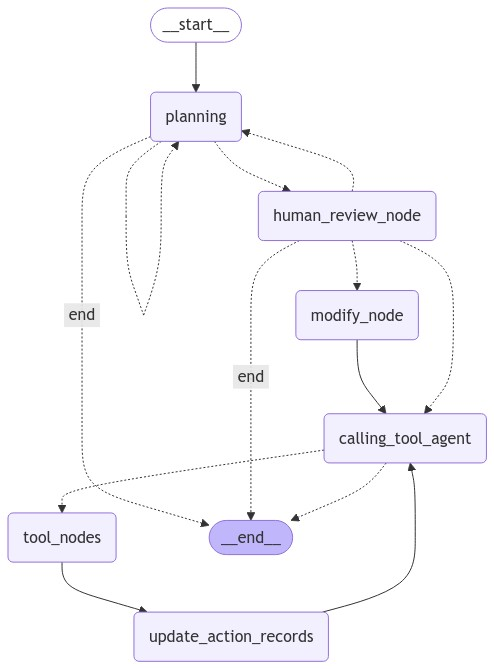

In [121]:
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import Literal
from langsmith import traceable
from langchain_core.runnables import RunnableLambda
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode

graph_builder = StateGraph(AgentState)

# 添加所有的节点
graph_builder.add_node("planning",planning_node)
graph_builder.add_node("human_review_node",human_review_node)
graph_builder.add_node("modify_node",modify_node)
graph_builder.add_node("calling_tool_agent",agent_node)
graph_builder.add_node("tool_nodes",tool_node)
graph_builder.add_node("update_action_records",update_action_records)

# tool_nodes = {"create_environment": create_environment,
#               "get_obs":get_obs_by_id,
#               "plot_grid":plot_layout_by_env_id,
#               "redispatch":redispatch}


# for node_name, tool in tool_nodes.items():
#     graph_builder.add_node(
#         node_name,
#         # The lambda ensures the function's string output is mapped to 
#         # the "observation"
#         # key in the AgentState
#         RunnableLambda(tool) | (lambda response: {"responses": response}),
#     )

action_map = {
    "create_environment": "create_environment",
    "initialize_graph": "initialize_graph",
    "plot_grid": "plot_grid",
    "redispatch": "redispatch",
    "unknown_action":END
}


graph_builder.add_edge(START, "planning")

graph_builder.add_conditional_edges("planning",
                                    route_after_planning, 
                                    {"planning":"planning",
                                     "end":END,
                                     "human_review_node":"human_review_node"
                                     })


graph_builder.add_conditional_edges("human_review_node",
                                    route_after_human,
                                   {
                                       "calling_tool_agent":"calling_tool_agent",
                                       "planning":"planning",
                                       "modify_node":"modify_node",
                                       "end":END
                                   })

graph_builder.add_edge("modify_node", "calling_tool_agent")

def should_continue(state: MessagesState):
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tool_nodes"
    return END


graph_builder.add_conditional_edges("calling_tool_agent", 
                                    should_continue,
                                   ["tool_nodes", END])


graph_builder.add_edge("tool_nodes", "update_action_records")

graph_builder.add_edge("update_action_records","calling_tool_agent")

graph = graph_builder.compile()

from IPython.display import Image, display


display(Image(graph.get_graph().draw_mermaid_png()))

### 使用图

In [128]:
async def call_agent(directives: str, max_steps: int = 10):
    # 确保传入的 'user_input' 在字典中
    event_stream = graph.stream(
        {
            "user_input": "帮我建立一个环境",  # 确保 'user_input' 包含用户的输入
            "responses": {},  # 确保 'responses' 是字典类型
        },
        {
            "recursion_limit": max_steps,  # 设置递归步数限制
        },
    )
    
    final_answer = None
    steps = []

    for event in event_stream:
        # 输出调试信息，查看 event 数据结构
        print(f"Event: {event}")

        if "agent" not in event:
            continue
        
        # 从事件中获取预测数据
        pred = event["agent"].get("prediction") or {}
        action = pred.get("action")
        action_input = pred.get("args", [])  # 获取参数，如果没有则初始化为空列表

        # 记录每一步的动作及其输入
        steps.append(f"{len(steps) + 1}. {action}: {action_input}")
        print("\n".join(steps))
        
        # 如果动作包含 "ANSWER"（假设这是你的终止条件），则提取最终答案
        if "ANSWER" in action:
            final_answer = action_input[0] if action_input else None
            break

    return final_answer

In [129]:
from langchain_core.prompts.chat import ChatPromptTemplate, HumanMessagePromptTemplate

# 定义 ChatPromptTemplate
prompt = ChatPromptTemplate.from_messages([
    HumanMessagePromptTemplate.from_template("{user_input}")
])

# 在实际调用时，确保 'user_input' 是从外部传入的
formatted_prompt = prompt.format(user_input="帮我建立一个环境，id使用1234")

In [130]:
for chunk in graph.stream(
    {"messages": [("human", "帮我建立一个l2rpn_case14_sandbox环境，id使用1234?")]}, stream_mode="values"
):
    chunk["messages"][-1].pretty_print()

InvalidUpdateError: Must write to at least one of ['env_name', 'env_id', 'actions', 'scratchpad', 'prediction', 'responses', 'plan', 'human_feedback']

2024-10-25 21:19:18,990 - langsmith.client - WARNING - Failed to batch ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/batch in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/batch', '{"detail":"Forbidden"}')
